In [1]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, chi2_contingency, kruskal
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the dataset
df = pd.read_csv(r'C:\Users\katch\Desktop\projects\wine_quality_prediction\notebooks\data\Wine_Quality_Data.csv')  
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [3]:

df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  color                 6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
color                   0
dtype: int64


In [5]:
numeric_df = df.select_dtypes(exclude=['object'])
numeric_df

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
6492,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
6493,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
6494,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
6495,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


In [6]:
def remove_outliers_all_columns(df, columns):
    mask = pd.Series(True, index=df.index)  
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        
        col_mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
        mask = mask & col_mask 
    return df[mask]

df_clean = remove_outliers_all_columns(df, numeric_df.columns)


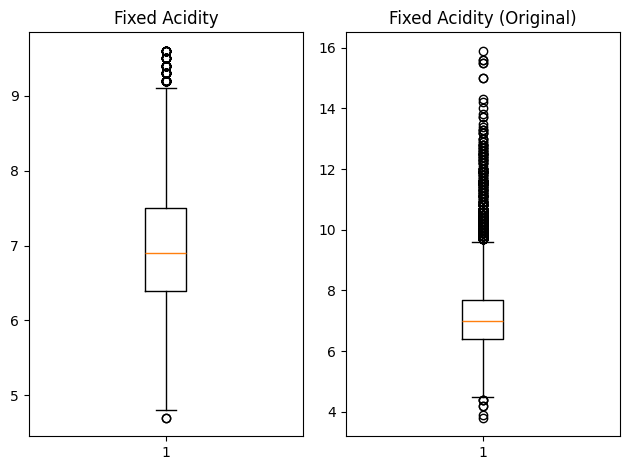

In [14]:
plt.subplot(1, 2, 1)
plt.boxplot(df_clean['fixed_acidity'])
plt.title('Fixed Acidity')

plt.subplot(1, 2, 2)
plt.boxplot(df['fixed_acidity'])
plt.title('Fixed Acidity (Original)')
plt.tight_layout()
plt.show()

In [16]:
def quality_labeler(quality):
    if quality <= 4:
        return 'low'
    elif quality <= 6:
        return 'medium'
    else:
        return 'high'

df_clean['quality_label'] = df_clean['quality'].apply(quality_labeler)


C:\Users\katch\AppData\Local\Temp\ipykernel_18876\3860214452.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['quality_label'] = df_clean['quality'].apply(quality_labeler)


# objectives

1. Is the average alcohol content significantly different between high-quality and low-quality wines?

2. Are the mean pH levels significantly different across multiple wine quality groups?

3. Is there an association between wine color (red vs. white) and wine quality categories?

#  Is the average alcohol content significantly different between high-quality and low-quality wines?

**Test type:** 

Independent two samples t-test (or Mann-Whitney U test if data is not normally distributed)

**Null hypothesis (H₀):** 

The mean alcohol content is the same for high and low-quality wines.

**Alternative hypothesis (H₁):** 

The mean alcohol content is different between the two quality groups.

In [17]:
high_quality = df_clean[df_clean['quality_label'] == 'high']['alcohol']
low_quality = df_clean[df_clean['quality_label'] == 'low']['alcohol']


In [19]:
# for checking data is normally distributed ?
from scipy.stats import shapiro, levene

# Normality check
print("High quality Shapiro:", shapiro(high_quality))
print("Low quality Shapiro:", shapiro(low_quality))

# Variance check
print("Levene’s Test:", levene(high_quality, low_quality))


High quality Shapiro: ShapiroResult(statistic=np.float64(0.9760933174138479), pvalue=np.float64(3.4605277614030293e-11))
Low quality Shapiro: ShapiroResult(statistic=np.float64(0.9576470095867141), pvalue=np.float64(0.0003087748313632875))
Levene’s Test: LeveneResult(statistic=np.float64(5.2646880594459216), pvalue=np.float64(0.0219570961068431))


Since the Shapiro–Wilk and Levene’s test p-values are less than 0.05, the data does not follow a normal distribution. Therefore, instead of a t-test, we will use the **Mann–Whitney U test**.

# Are the mean pH levels significantly different across multiple wine quality groups?

**Test type:**

One-way ANOVA (or Kruskal–Wallis test if data is not normally distributed)

**Null hypothesis (H₀):**

The mean pH levels are the same across all wine quality groups.

**Alternative hypothesis (H₁):**

At least one wine quality group has a different mean pH level compared to the others.

In [23]:
high_quality_ph = df_clean[df_clean['quality_label'] == 'high']['pH']
low_quality_ph = df_clean[df_clean['quality_label'] == 'low']['pH']
medium_quality_ph = df_clean[df_clean['quality_label'] == 'medium']['pH']

In [24]:
from scipy.stats import kruskal

h_stat, p_val = kruskal(high_quality_ph, low_quality_ph, medium_quality_ph)
print(f"H-statistic: {h_stat}")
print(f"P-value: {p_val:.6f}")

if p_val < 0.05:
    print("Reject H0: Significant difference in pH levels between high, medium, and low quality wines.")
else:
    print("Fail to reject H0: No significant difference in pH levels.")


H-statistic: 9.196521086306772
P-value: 0.010069
Reject H0: Significant difference in pH levels between high, medium, and low quality wines.


The Kruskal–Wallis test produced an H-statistic of 9.20 and a p-value of 0.0101. Since the p-value is less than the 0.05 significance level, we **reject the null hypothesis (H₀)**. This indicates a **statistically significant difference in pH levels among high-, medium-, and low-quality wines**.

The Mann–Whitney U test yielded a U-statistic of 98,341.5 and a p-value of < 0.05. Since the p-value is far below the 0.05 significance level, we **reject the null hypothesis (H₀)**. This indicates a **statistically significant difference in alcohol content between high-quality and low-quality wines**.

# Is there an association between wine color (red vs. white) and wine quality categories?

**Test type:**

Chi-squared test of independence

**Null hypothesis (H₀):**

Wine color and wine quality category are independent (no association).

**Alternative hypothesis (H₁):**

There is an association between wine color and wine quality category.

# chi-square test

In [26]:
from scipy.stats import chi2_contingency

contingency_table = pd.crosstab(df_clean['quality_label'], df_clean['color'])
chi2_stat, p_val, dof, ex = chi2_contingency(contingency_table)

print(f"Chi-squared Statistic: {chi2_stat}")
print(f"P-value: {p_val}")
print(f"Degrees of Freedom: {dof}")
print(f"Expected Frequencies: \n{ex}")

if p_val < 0.05:
    print("Reject H0: Significant association between wine quality and alcohol content.")
else:
    print("Fail to reject H0: No significant association between wine quality and alcohol content.")


Chi-squared Statistic: 30.49053604165642
P-value: 2.3936697058354485e-07
Degrees of Freedom: 2
Expected Frequencies: 
[[ 130.34090909  794.65909091]
 [  19.30454545  117.69545455]
 [ 532.35454545 3245.64545455]]
Reject H0: Significant association between wine quality and alcohol content.


The Chi-squared test yielded a χ² statistic of 30.49 with 2 degrees of freedom and a p-value of 2.39 × 10⁻⁷. Since the p-value is far below the 0.05 significance level, we **reject the null hypothesis (H₀)**. This indicates a **statistically significant association between wine quality and alcohol content**.